In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap,
                receptor_distances,
                full_array_entropy,
                mean_receptor_distance)
from run import initialize,train,test
# 2. Apply the REVTeX look using internal fonts
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],      # Times-like font bundled with MPL
    "mathtext.fontset": "cm",           # Computer Modern math look
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 0.8,
    "font.size": 11
})

In [ ]:
n_units=5
k_sub = 5
n_families = 1
N_train = 2**17
N_test = 2**14
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 3,
        "k_sub": k_sub,
        "batch_size": N_train,
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 1.,
        "tolerant":False, # set whether we want tolerance for heteromers on the covariance loss
        "optimizer":"Adam",
        "momentum":0.9,
        "exact_loss":True,
        "temperature":0.1
    }

In [3]:
env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)

Fitting UMAP... (This may take a few seconds)


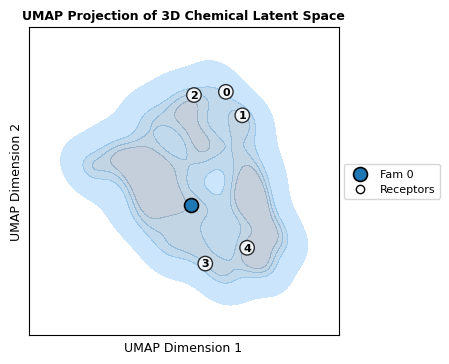

In [4]:
fig,ax = plot_latent_umap(env,CONF['receptor_indices'])
#fig.savefig('../../data/fig/1fam_pre_opt.svg',bbox_inches='tight')

In [6]:
train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance])

Training for 50000 epochs...


Fitting UMAP... (This may take a few seconds)


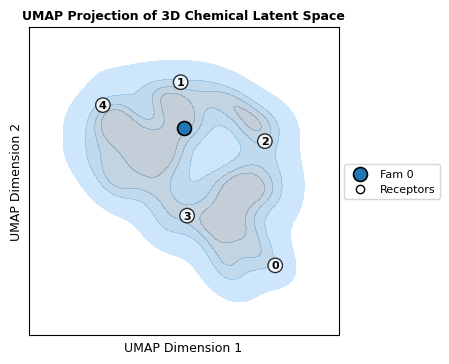

In [10]:
fig,ax = plot_latent_umap(env,CONF['receptor_indices'])
fig.savefig('../../data/fig/1fam_post_opt.pdf',bbox_inches='tight')

In [50]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create the figure
fig = plt.figure(figsize=(8, 4))

# Use GridSpec: Left side (broken axis) and Right side (normal axis)
# we give the left side more 'width_ratios' if needed, but 1:1 is fine
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.3)

# --- LEFT SIDE: THE BROKEN AXIS ---
# Create two subplots inside the left area
gs0 = gs[0].subgridspec(2, 1, hspace=0.05, height_ratios=[4, 1])
ax0_top = fig.add_subplot(gs0[0])
ax0_bot = fig.add_subplot(gs0[1])

# 1. Plot the outlier on the top part
ax0_bot.plot([0], [train_out['full_array_entropy'][0]], 'o', color='tab:blue')

# 2. Plot the rest on the bottom part
ax0_top.plot(range(1, len(train_out['full_array_entropy'])), 
             train_out['full_array_entropy'][1:], color='tab:blue')

# 3. Set the limits to create the "break"
# Adjust these values based on your actual data ranges
ax0_bot.set_ylim(train_out['full_array_entropy'][0] , train_out['full_array_entropy'][0])
ax0_top.set_ylim(min(train_out['full_array_entropy'][1:]), 
                 max(train_out['full_array_entropy'][1:]))

# 4. Hide spines and ticks to make it look like one axis
ax0_top.spines['bottom'].set_visible(False)
ax0_bot.spines['top'].set_visible(False)
ax0_top.xaxis.tick_top()
ax0_top.tick_params(labeltop=False) # don't want labels on top
ax0_bot.xaxis.tick_bottom()
ax0_bot.set_xlim(-2,100)

# 5. Add the "break" diagonal marks
d = .015  # size of the lines
kwargs = dict(transform=ax0_top.transAxes, color='k', clip_on=False)
ax0_top.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax0_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax0_bot.transAxes)  
ax0_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax0_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs) # bottom-right diagonal

# Labels for the left group
ax0_bot.set_xlabel('optimization steps (%)')
fig.text(0.04, 0.5, 'MI', va='center', rotation='vertical') # Shared Y-label

# --- RIGHT SIDE: NORMAL AXIS ---
ax1 = fig.add_subplot(gs[1])
ax1.plot(train_out['mean_receptor_distance'])
ax1.set_ylabel('Average inter-receptor distances')
ax1.set_xlabel('optimization steps (%)')

plt.savefig('entropy_distance.pdf',bbox_inches='tight')

/tmp/ipykernel_175352/937574352.py:26: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax0_bot.set_ylim(train_out['full_array_entropy'][0] , train_out['full_array_entropy'][0])


RuntimeError: Failed to process string with tex because latex could not be found

Error in callback <function _draw_all_if_interactive at 0x7d9fded3e680> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 800x400 with 3 Axes>

In [29]:
CONF.update({"receptor_indices":generate_cascading_receptors(n_units=5, k_sub=k_sub, n_sensors=10)})
env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)

Fitting UMAP... (This may take a few seconds)


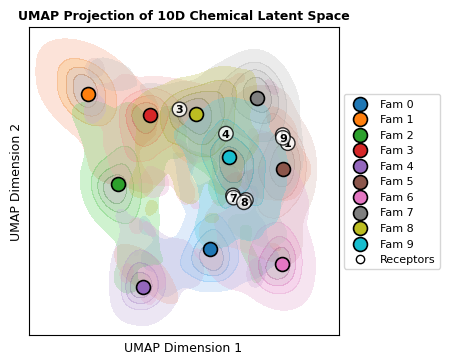

In [30]:
fig,ax = plot_latent_umap(env,CONF['receptor_indices'])
fig.savefig('../../data/fig/10fam_pre_opt_het.svg',bbox_inches='tight')

In [31]:
train_out = train(CONF, env, rec, loss_fn, optimize)

Training for 5000 epochs...


Fitting UMAP... (This may take a few seconds)


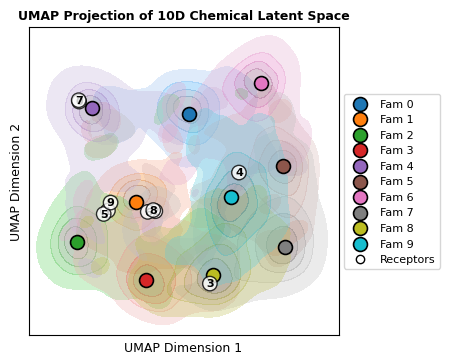

In [32]:
fig,ax = plot_latent_umap(env,CONF['receptor_indices'])
fig.savefig('../../data/fig/10fam_post_opt_het.svg',bbox_inches='tight')

Fitting UMAP... (This may take a few seconds)


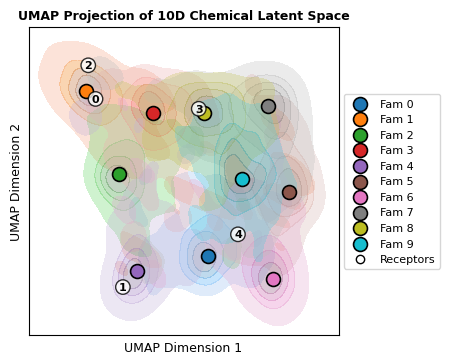

In [33]:
fig,ax = plot_latent_umap(env,torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long))

In [ ]:
plt.plot(train_out['full_array_entropy'])